In [63]:
import numpy as np
import cv2
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid

In [64]:
image1=cv2.imread("h2114153  h&e_ROI_1 Epithelia copy.png")
image1_gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
_,whole_thresh=cv2.threshold(image1_gray,1,255,cv2.THRESH_BINARY)

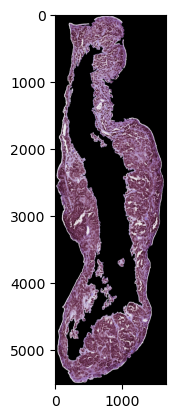

In [66]:
plt.imshow(image1);

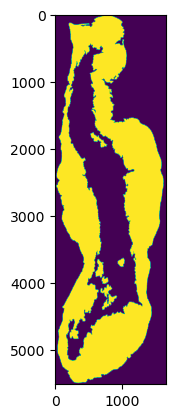

In [67]:
plt.imshow(whole_thresh);

In [68]:
contours,hierarchy=cv2.findContours(whole_thresh,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

In [69]:
contour_image = np.zeros_like(whole_thresh)

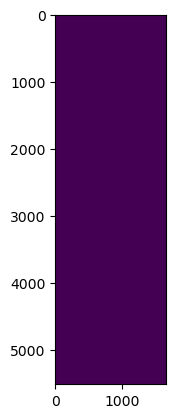

In [70]:
plt.imshow(contour_image);

In [71]:
drawn_contour = cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 20)

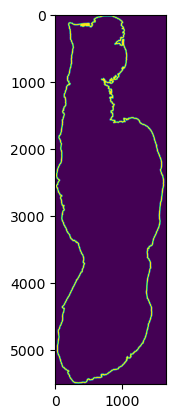

In [72]:
plt.imshow(drawn_contour);

In [73]:
all_normals=[]

In [74]:
len(contours)

1

In [75]:
contour = contours[0]

In [78]:
type(contour)

numpy.ndarray

In [77]:
np.max(contour)

5499

In [79]:
contour.shape

(6209, 1, 2)

In [ ]:
contour[]

In [ ]:


#Loop over all contours in image
for contour in contours:
    #Reshape into xy pairings
    points=contour.reshape(-1,2)
    n_points=len(points)
    tangents=np.zeros_like(points,dtype=float)

    #Calculate tangent using smoothing
    #Higher smoothingn values result in less "jutty" squares, but can work poorly on smaller regions of epithelium
    for i in range(n_points):
        prev_idx=(i-smoothing_size)%n_points
        next_idx=(i+smoothing_size)%n_points
        tangent=points[next_idx]-points[prev_idx]
        tangent=tangent/(np.linalg.norm(tangent)+1e-8)
        tangents[i]=tangent
        

    #Convert to normal
    normals=np.zeros_like(tangents)
    normals[:,0]=-tangents[:,1]
    normals[:,1]=tangents[:,0]
    
    #add to list of all contour normals
    all_normals.append(normals)